In [115]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import json

import sys
sys.path.append("../../Scripts/")
from Evolution import *

Evolutionary Model Used in the Paper:

In [116]:
Model_Attributes_location = "../../../Model_Parameters/Evolver_simulation/Model_Attributes.json"
with open(Model_Attributes_location, 'r') as file:
    Model_Details = json.load(file)


In [117]:
print("Number of Positions =", Model_Details['Number_of_Positions'])
print("Number of Alleles per position =", Model_Details['Number_of_Alleles'])
print("")
print("Features in each partition =", Model_Details['Feature_Partition'])


Number of Positions = 16
Number of Alleles per position = 4

Features in each partition = [4, 4, 4, 4]


In [118]:
print("="*100)
for k in Model_Details.keys():
    print("||->",k, ":", Model_Details[k])
print("="*100)


||-> Feature_Partition : [4, 4, 4, 4]
||-> Number_of_Positions : 16
||-> Number_of_Alleles : 4
||-> Fitness_type : Conditional_Additive
||-> Zero_fitness_death : True
||-> Weights : [0.9920400904402258, 0.962880881706722, 0.9998765436859355, 0.971551987343159, 1.0342033078386703, 0.9976988451982086, 1.0230610082929552, 0.961248450235667, 0.520845931038242, 0.4919911061241495, 0.516498035023754, 0.5032598836570324, 0.0, 0.0, 0.0, 0.0]
||-> Mutation_Rate : 0.3
||-> Competetion_fration : 0.3
||-> Tournament_Type : Probabilistic
||-> Selection_Strength : 4
||-> Fitness_Landscape_Constraint : Max_Hamming
||-> Fitness_Landscape_String : ['3002023230213133', '3002023230213133', '3002023230210010', '3002023230210010', '3002023203321222', '3002023203321222', '3002023203322301', '3002023203322301', '3002211112100332', '3002211112100332', '3002211112101031', '3002211112101031', '3002211121032023', '3002211121032023', '3002211121033320', '3002211121033320']


In [119]:
Feature_Partition = Model_Details["Feature_Partition"]
Number_of_letters = Model_Details["Number_of_Alleles"]
Weights = Model_Details['Weights']
Mutation_Rate = Model_Details['Mutation_Rate']
Compete_fraction = Model_Details['Competetion_fration']
Population_size = 1000
Epochs = 10000
Num_features = np.sum(Feature_Partition)


### Lets load the fitness landscape used
fit_landscape = Model_Details['Fitness_Landscape_String']

## we want to convert this to a usable form:
Fitness_Landscape =[]
for elem in fit_landscape:
    elem_split = list(elem)
    Fitness_Landscape.append(elem_split)

Fitness_Landscape = np.array(Fitness_Landscape).astype(int)
    

In [120]:
Letters = np.unique(Fitness_Landscape)

C1 = ["salmon", "purple", "blue", "green"]

Custom_map0 =  mcolors.ListedColormap(C1)

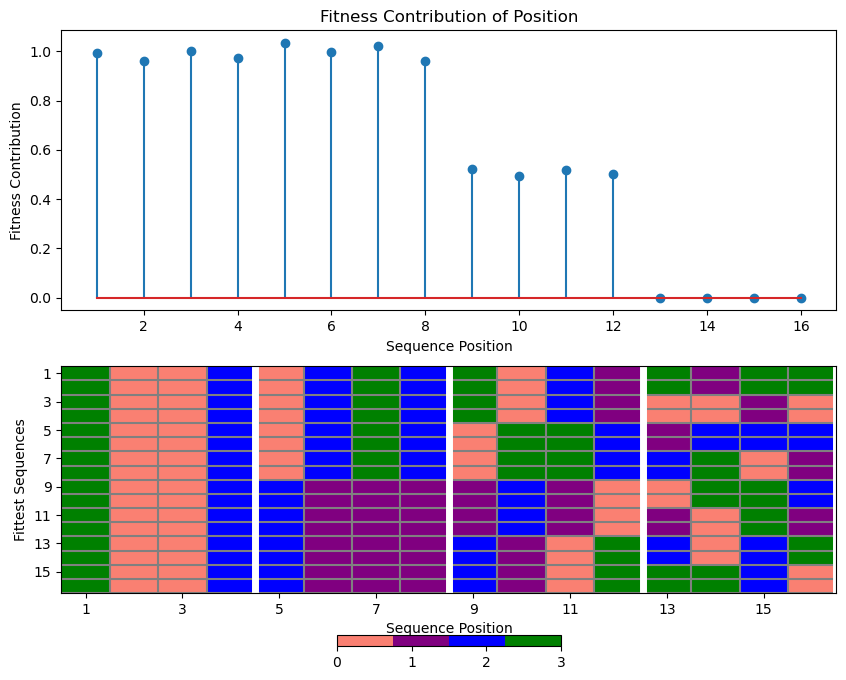

In [121]:
fig, ax = plt.subplots(2,1,figsize=(10,8))
ax[0].stem(range(1, Num_features+1,1), Weights)
ax[0].set_title("Fitness Contribution of Position")
ax[0].set_xlabel("Sequence Position")
ax[0].set_ylabel("Fitness Contribution")

f1= ax[1].imshow(Fitness_Landscape, cmap = Custom_map0,aspect = "auto")
plt.colorbar(f1, ax=ax[1],ticks= Letters, cmap = "Custom_map0", location = "bottom", fraction = 0.04)
ax[1].set_xlabel("Sequence Position")
ax[1].set_ylabel("Fittest Sequences")
ax[1]. set_yticks(range(0, Num_features,2), range(1,Num_features+1,2))
ax[1]. set_xticks(range(0, Num_features,2), range(1,Num_features+1,2))


### guide lines
for i in range(0, np.shape(Fitness_Landscape)[0]):
    ax[1].axhline(i+0.5, color = "gray")
for i in range(0, np.shape(Fitness_Landscape)[1]):
    ax[1].axvline(i+0.5, color = "gray")
for i,elem in enumerate(np.cumsum(Feature_Partition)):
    ax[1].axvline(elem-0.5, linewidth = 5, color = "white")


 
    



### Starting the Simulation:
Lets define the parameters of the evolved population.
Namely, :

    1. the size and the
    2. number of epochs that this evolutionary game goes on for.

In [37]:
## Lets input the relevant parameters for the simulation.
Population_size = 2000
Epochs = 1000

In [38]:
print("-"*80)
Evolver = Evolution_simulation(Feature_Partition, Number_of_letters)
Evolver.Fitness_Sequence = Fitness_Landscape
Evolver.Set_mutation_rate(Mutation_Rate)
Evolver.Set_compete_fraction(Compete_fraction)
Evolver.Weights = Weights
Initial_Population = Evolver.Population(Population_size)
print("-"*80)


--------------------------------------------------------------------------------
--------------------------------------------------------------------------------


Text(0.5, 0, 'Sequence Position')

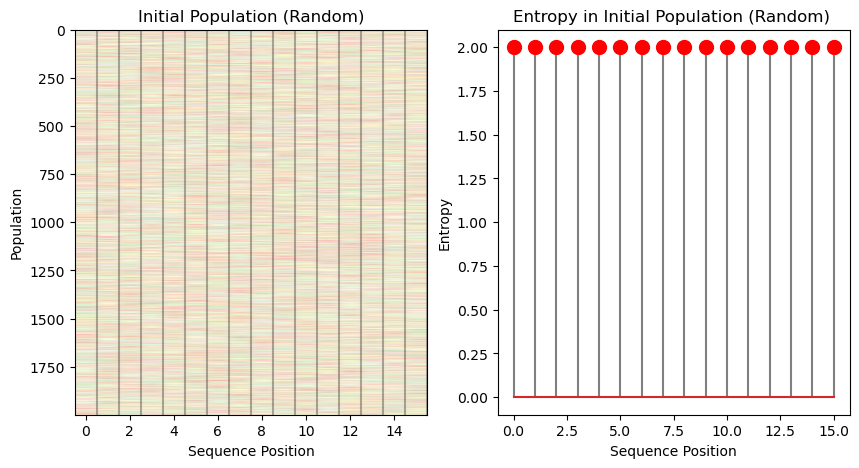

In [39]:
P_I = Initial_Population.copy()
Pop_entropy_initial = Evolver.Shannon_Entropy(Initial_Population)


fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(P_I, aspect='auto', cmap='Pastel1_r')
ax[0].set_xlabel("Sequence Position")
ax[0].set_ylabel("Population")

for k in range(0, Num_features):
    ax[0].axvline(k+0.5, color = "black", alpha = 0.3)
ax[0].set_title("Initial Population (Random)")


ax[1].stem(Pop_entropy_initial, "gray")
ax[1].plot(Pop_entropy_initial, "ro" , ms = 10, zorder = 2)
ax[1].set_title("Entropy in Initial Population (Random) ")
ax[1].set_ylabel("Entropy")
ax[1].set_xlabel("Sequence Position")

In [ ]:
### Lets evolve this Population:

Fitness_Evolution = []
Fitness_bins = np.linspace(0, 100,50)
show_progress = False
step = 1
P_I = Initial_Population.copy()
for i in tqdm(range(0, Epochs, step)):
    Population_fin = Evolver.Tournament(step, P_I, show_progress= show_progress )
    fitness_i = []
    for i in range(0, len(Population_fin)):
        f_ind= Evolver.Fitness_Measurement(Population_fin[i])
        fitness_i.append(f_ind)
    cts, bins = np.histogram(fitness_i, Fitness_bins)
    Fitness_Evolution.append(cts)
    
    P_I = Population_fin

In [63]:
Fitness_Evolution_hist = np.array(Fitness_Evolution)

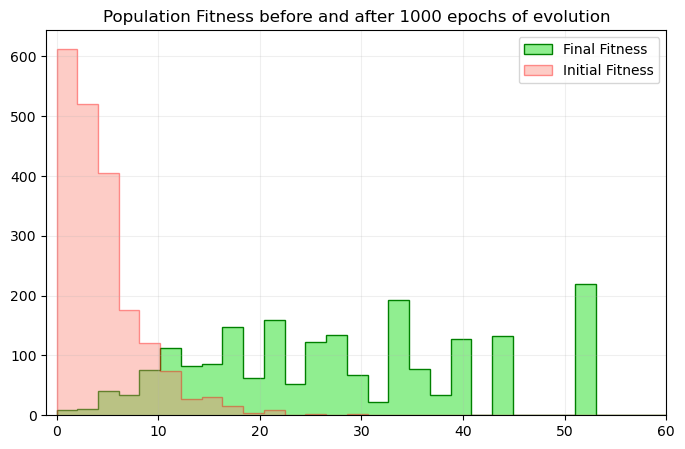

In [110]:
plt.figure(figsize=(8,5))
plt.stairs(Fitness_Evolution_hist[-1], edges=Fitness_bins, edgecolor = "green",
            linewidth=1,fill = True, label = "Final Fitness", color = "lightgreen")
plt.stairs(Fitness_Evolution_hist[0], edges=Fitness_bins,edgecolor = "red", 
            linewidth=1 ,fill = True, label = "Initial Fitness", alpha = 0.4, color = "salmon")



plt.title(f"Population Fitness before and after {Epochs} epochs of evolution")
plt.grid(alpha = 0.2, zorder = 0)
plt.xlim(-1, 60)
plt.legend()
plt.show()

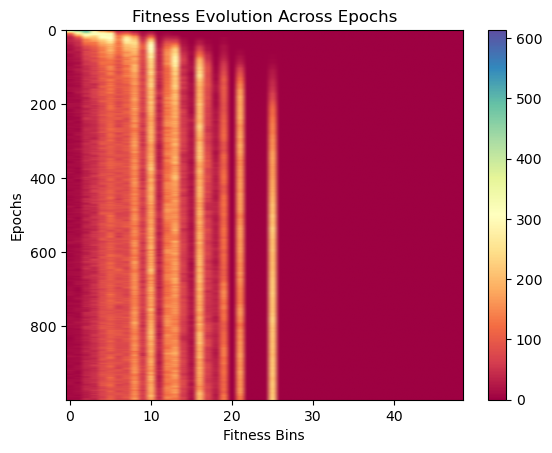

In [109]:
plt.imshow(Fitness_Evolution_hist, aspect= "auto", cmap = "Spectral")
plt.xlabel("Fitness Bins")
plt.colorbar()
plt.ylabel("Epochs")
plt.title("Fitness Evolution Across Epochs")
plt.show()
